In [259]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [260]:
sign_image_path = "./Task-1/rh_sign.jpg"
scene_image_path = "./Task-1/img2.png"

# Load images
sign_image = cv2.imread(sign_image_path, cv2.IMREAD_COLOR)
scene_image = cv2.imread(scene_image_path, cv2.IMREAD_COLOR)

In [261]:
def bgr_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [262]:
def hsv_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_HSV2RGB)

In [263]:

def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [264]:
def boost_reds(image):
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Split HSV channels
    h, s, v = cv2.split(hsv)

    # Target red hues (0-10 and 160-180 degrees in HSV)
    mask1 = cv2.inRange(h, 0, 10)
    mask2 = cv2.inRange(h, 160, 180)
    red_mask = cv2.bitwise_or(mask1, mask2)

    # Boost saturation for red hues
    s = cv2.addWeighted(s, 1.0, red_mask, 0.1, 0)  # Add 10% of the red mask to saturation

    # Merge channels and convert back to BGR
    boosted_hsv = cv2.merge((h, s, v))
    boosted_image = cv2.cvtColor(boosted_hsv, cv2.COLOR_HSV2BGR)

    return boosted_image


In [265]:
def boost_contrast(image):
    # Create a CLAHE object with specified clip limit and tile grid size
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Convert the image to LAB color space (to apply CLAHE only to the L channel)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Split the LAB image into L, A, and B channels
    l, a, b = cv2.split(image_lab)

    # Apply CLAHE to the L channel (lightness channel)
    l_clahe = clahe.apply(l)

    # Merge the CLAHE enhanced L channel back with the A and B channels
    image_lab_clahe = cv2.merge((l_clahe, a, b))

    # Convert the image back to BGR color space
    image = cv2.cvtColor(image_lab_clahe, cv2.COLOR_LAB2BGR)

    return image

def to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


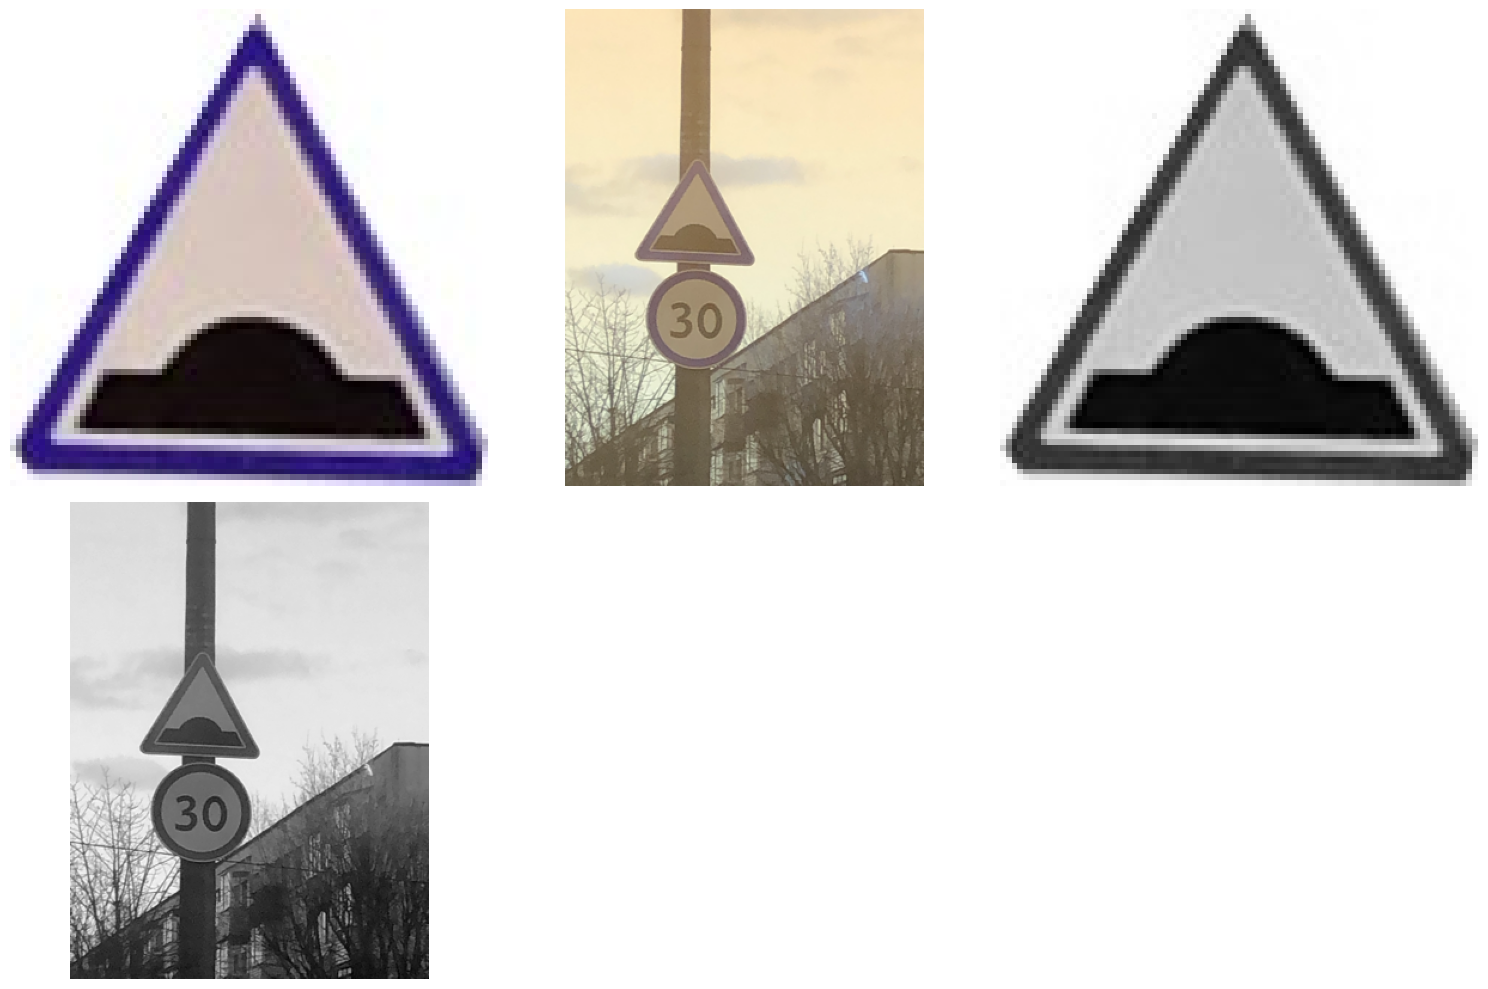

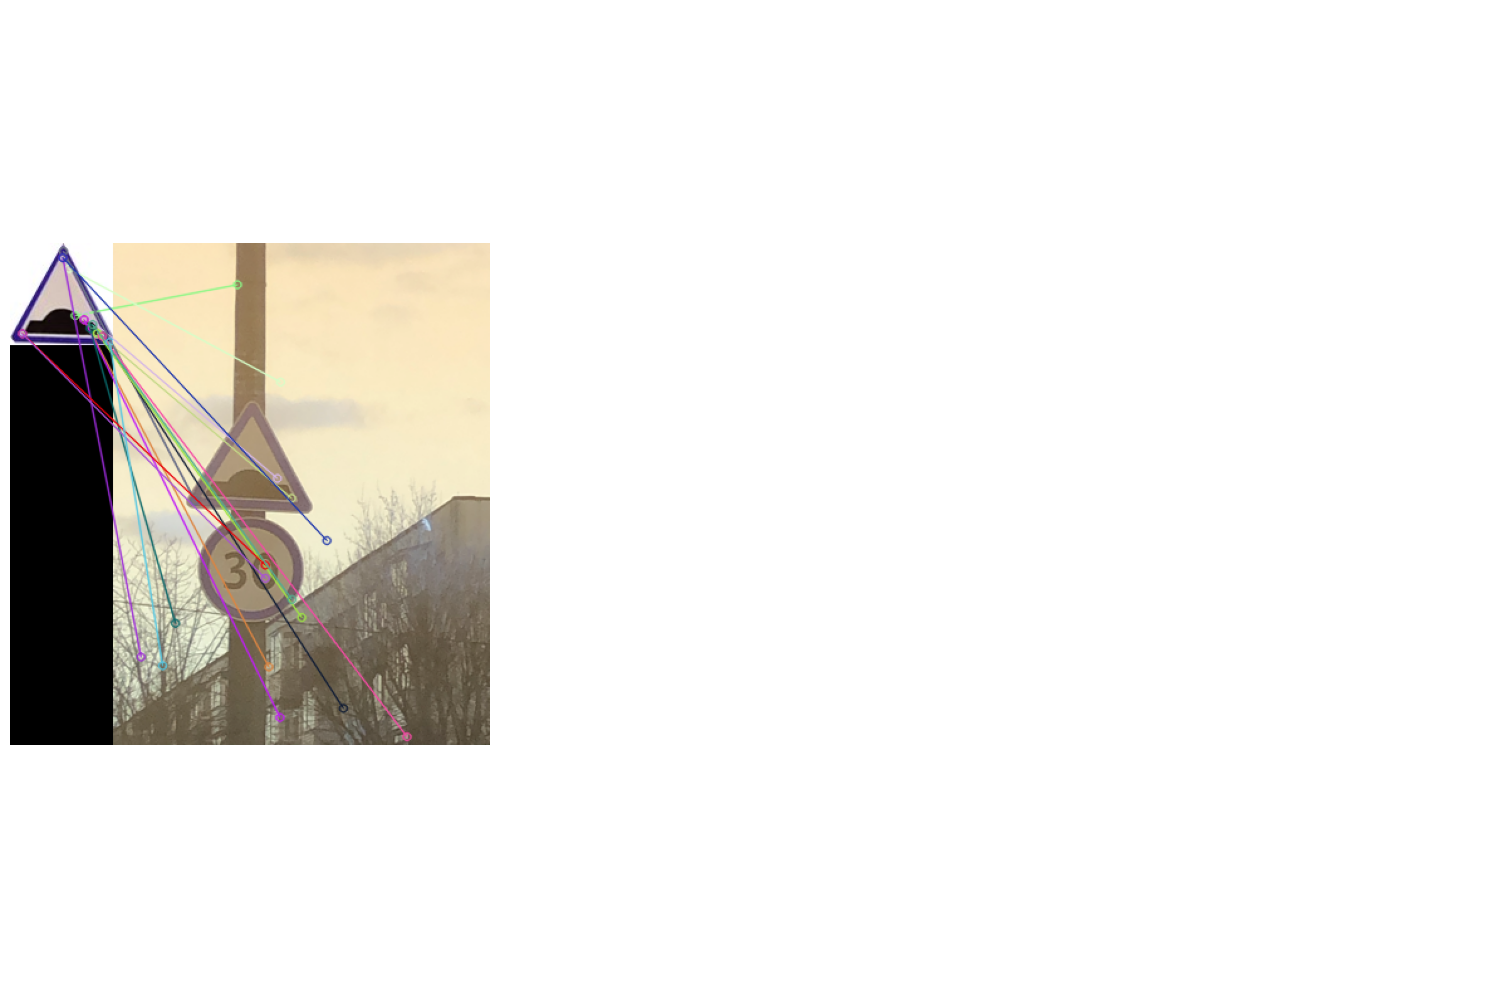

H [[-1.84307616e-01  1.40172244e-01 -1.47952782e+00]
 [-9.30513563e+00  4.52135306e+00  3.33260772e+02]
 [-2.93189246e-02  1.49731954e-02  1.00000000e+00]]


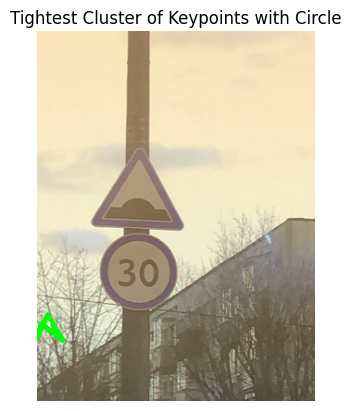

In [ ]:
def preprocess_with_edges(image):
    """Preprocess the image using edge detection."""
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    edges = cv2.Canny(blurred, 70, 150)  # Edge detection
    return edges

# Load the reference and search images
reference_image = cv2.imread(sign_image_path)
search_image = cv2.imread(scene_image_path)

# Step 1: Detect edges in both images
preprocessed_ref = to_grayscale(boost_contrast(reference_image))
preprocessed_search = to_grayscale(boost_contrast(search_image))

plot_images([reference_image, search_image, preprocessed_ref, preprocessed_search])

# # Step 4: Apply SIFT feature matching
sift = cv2.SIFT_create()

# # Detect keypoints and descriptors in the reference and search images
keypoints_ref, descriptors_ref = sift.detectAndCompute(reference_image, None)
keypoints_search, descriptors_search = sift.detectAndCompute(search_image, None)

# # Use BFMatcher to match the descriptors
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors_ref, descriptors_search)

# # Sort the matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# # Draw the matches on a new image
result = cv2.drawMatches(reference_image, keypoints_ref, search_image, keypoints_search, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plot_images([result])

# Extract points from the matches
src_pts = np.float32([keypoints_ref[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([keypoints_search[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

print("H", H)

height, width = reference_image.shape[:2]

# Define the corners of the reference image
corners = np.array([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
], dtype='float32')

corners = corners.reshape(-1, 1, 2)

# Apply the homography to the corners
transformed_corners = cv2.perspectiveTransform(corners, H)

# Draw the bounding box on the search image
result = cv2.polylines(search_image, [np.int32(transformed_corners)], isClosed=True, color=(0, 255, 0), thickness=3)

# Show the result
plt.imshow(result)
plt.title('Tightest Cluster of Keypoints with Circle')
plt.axis('off')
plt.show()
